In [13]:
import os

import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader

from src.patchers.collate import pad_patches_collate

from src.id_dataset import IdDataset
from src.patchers.patcher_config import PatcherConfig

In [14]:
PATCH_COUNT = 20
PATCH_HEIGHT, PATCH_WIDTH = 40, 20
BATCH_SIZE = 15

SUBSET_PATH = os.path.join("..", "..", "data", "lines.filtered_max_width.all")
LMDB_PATH = os.path.join("..", "..", "data", "lmdb.hwr_40-1.0")

In [15]:
grid_patcher_config = PatcherConfig(
    method="grid",
    random_seed=42,
    patch_width=PATCH_WIDTH,
    patch_height=PATCH_HEIGHT,
)
random_patcher_config = PatcherConfig(
    method="random",
    patch_count=PATCH_COUNT,
    random_seed=42,
    patch_width=PATCH_WIDTH,
    patch_height=PATCH_HEIGHT,
)
sift_patcher_config = PatcherConfig(
    method="sift",
    patch_count=PATCH_COUNT,
    random_seed=42,
    patch_width=PATCH_WIDTH,
    patch_height=PATCH_HEIGHT,
)

grid_dataset = IdDataset(
    SUBSET_PATH,
    LMDB_PATH,
    augment=False,
    patcher_config=grid_patcher_config,
    test=True
)
grid_dataloader = DataLoader(
    grid_dataset,
    num_workers=0,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    collate_fn=pad_patches_collate,
)

random_dataset = IdDataset(
    SUBSET_PATH,
    LMDB_PATH,
    augment=False,
    patcher_config=random_patcher_config,
    test=True
)
random_dataloader = DataLoader(
    random_dataset,
    num_workers=0,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

sift_dataset = IdDataset(
    SUBSET_PATH,
    LMDB_PATH,
    augment=False,
    patcher_config=sift_patcher_config,
    test=True
)
sift_dataloader = DataLoader(
    sift_dataset,
    num_workers=0,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

In [16]:
def image_convert_plottable(image: np.ndarray | torch.Tensor) -> np.ndarray:

    if isinstance(image, torch.Tensor):
        image = image.cpu().numpy()

    if image.ndim == 3 and image.shape[0] in (1, 3):
        image = np.transpose(image, (1, 2, 0))  # CHW -> HWC

    # squeeze single channel for matplotlib (H, W, 1) -> (H, W)
    if image.ndim == 3 and image.shape[2] == 1:
        image = image[:, :, 0]

    return image

In [17]:
def show_image(image, figsize=(12, 5)):

    image = image_convert_plottable(image)

    plt.figure(figsize=figsize)
    plt.imshow(image, cmap="gray")
    plt.title("Original Image (without patches)")
    plt.axis("off")

In [18]:
def show_patches(patches, cols=5, figsize=(20, 10)):

    n = len(patches)
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=figsize)

    for i in range(n):
        patch = image_convert_plottable(patches[i])

        plt.subplot(rows, cols, i + 1)
        plt.imshow(patch, cmap="gray")
        plt.title(f"Patch {i}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

Image1 shape: torch.Size([1, 40, 1194])
Image1 patches shape: torch.Size([60, 1, 40, 20])


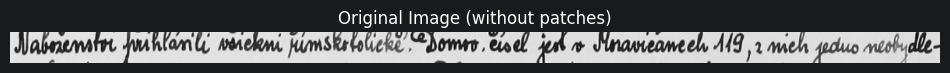

In [19]:
rand_idx = np.random.randint(len(grid_dataset))

image1 = grid_dataset.get_original_image1(rand_idx)
image1_patches, _, _ = grid_dataset[rand_idx]

print("Image1 shape:", image1.shape)
print("Image1 patches shape:", image1_patches.shape)

show_image(image1)

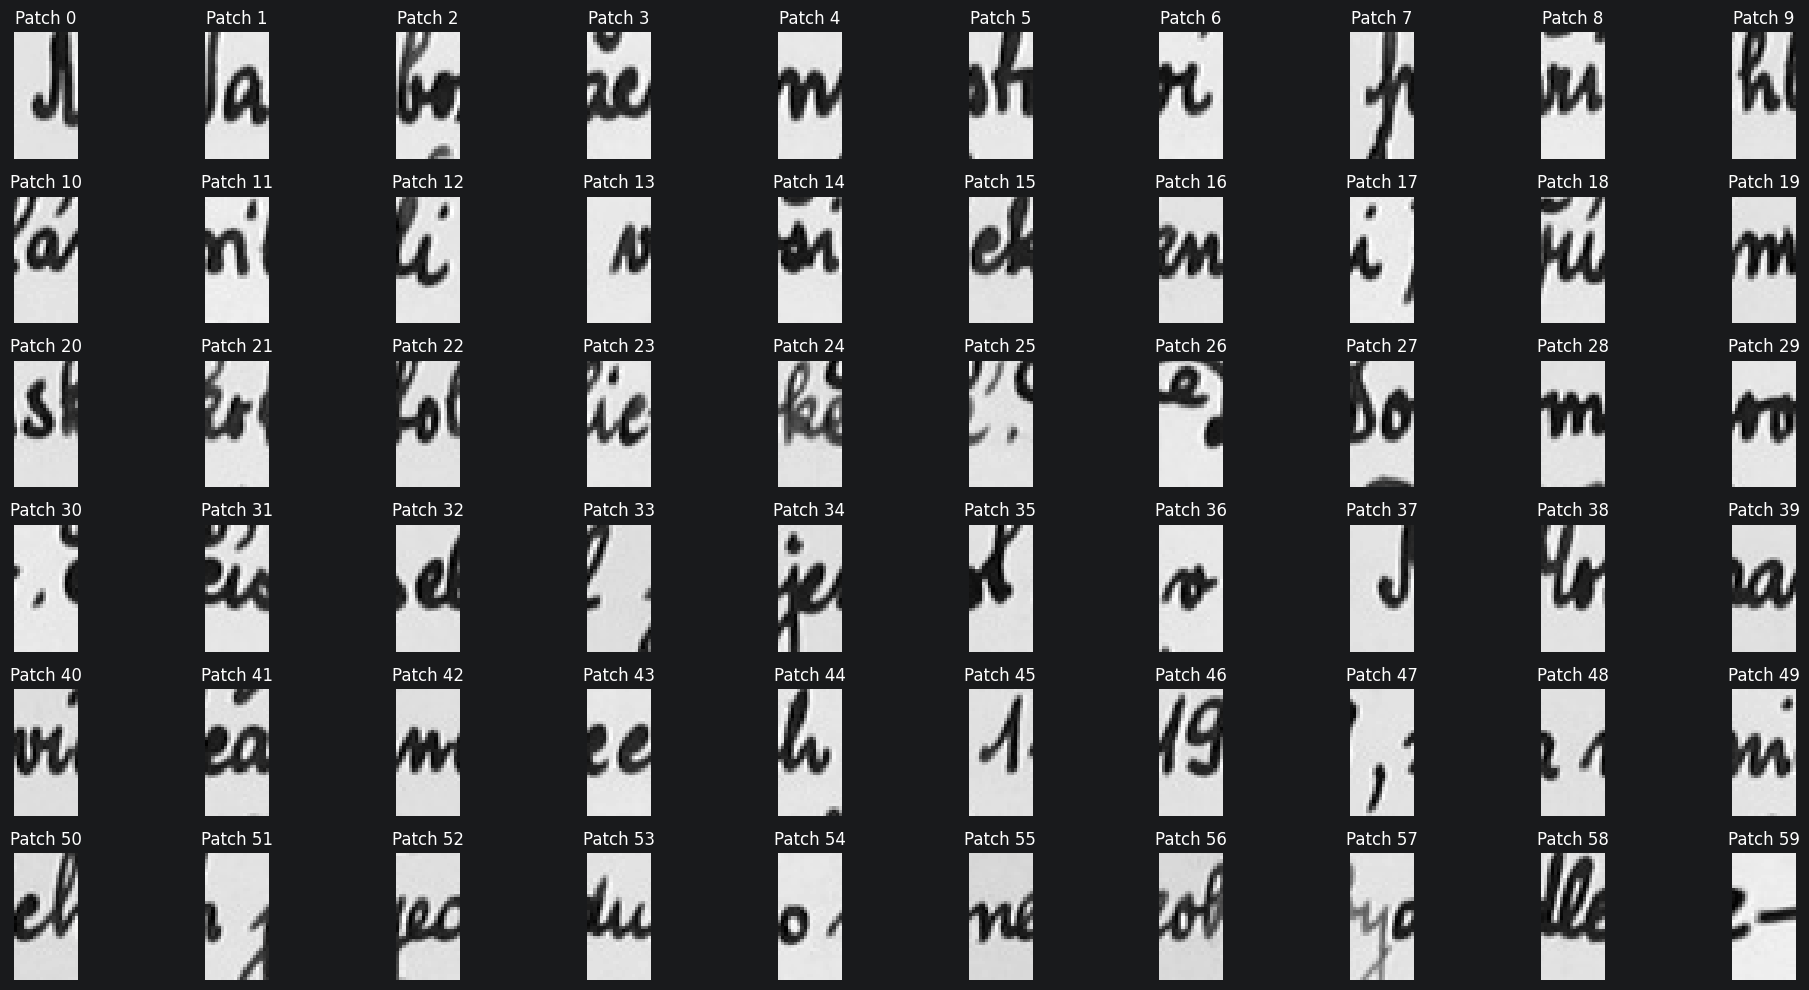

In [20]:
show_patches(image1_patches, cols=10)

Image1 shape: torch.Size([1, 40, 680])
Image1 patches shape: torch.Size([20, 1, 40, 20])


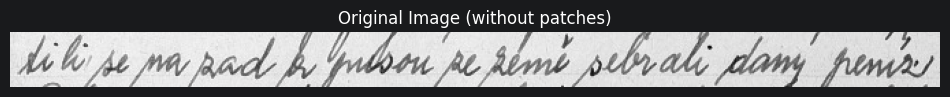

In [21]:
rand_idx = np.random.randint(len(random_dataset))

image1 = random_dataset.get_original_image1(rand_idx)
image1_patches, _, _ = random_dataset[rand_idx]

print("Image1 shape:", image1.shape)
print("Image1 patches shape:", image1_patches.shape)

show_image(image1)

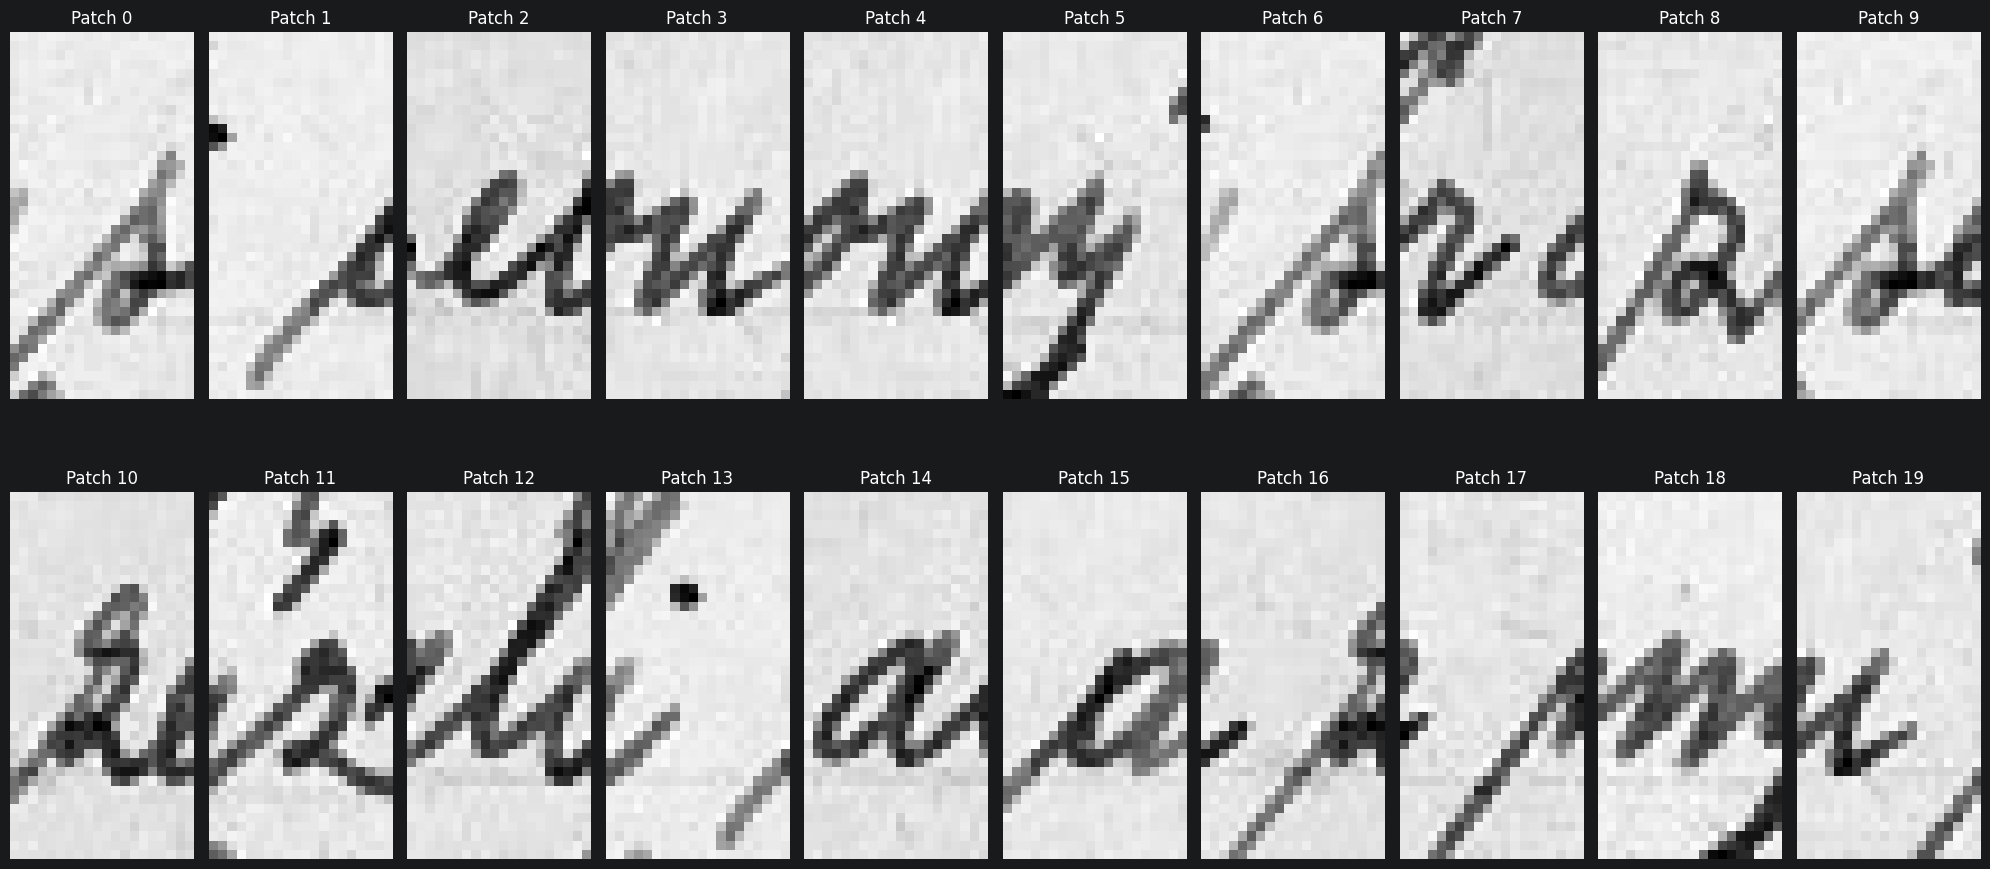

In [22]:
show_patches(image1_patches, cols=10)

Image1 shape: torch.Size([1, 40, 961])
Image1 patches shape: torch.Size([20, 1, 40, 20])


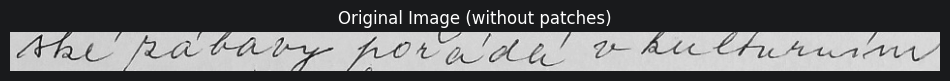

In [43]:
rand_idx = np.random.randint(len(sift_dataset))

image1 = sift_dataset.get_original_image1(rand_idx)
image1_patches, _, _ = sift_dataset[rand_idx]

print("Image1 shape:", image1.shape) 
print("Image1 patches shape:", image1_patches.shape)

show_image(image1)

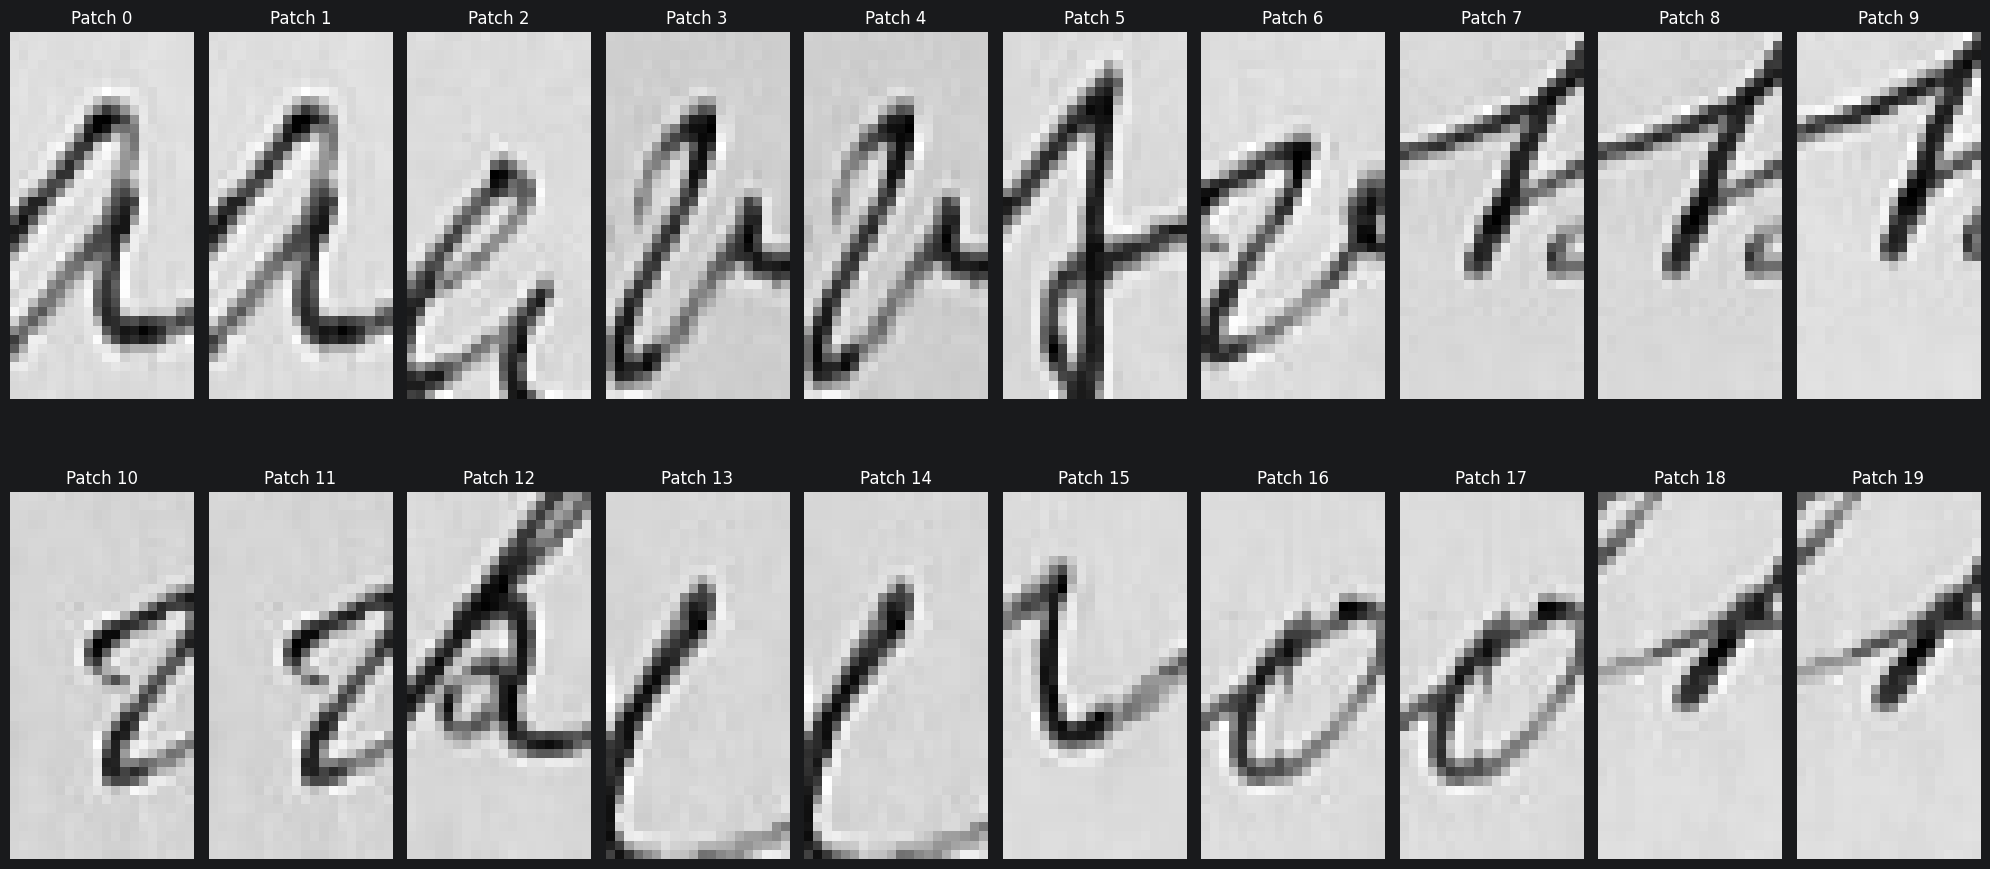

In [44]:
show_patches(image1_patches, cols=10)